# **Análisis de Perfiles de Clientes Multiproducto - Banco Atlas**
# **Sprint 3: Segmentación con K-Prototypes**

**Objetivo:** Identificar las combinaciones de características demográficas más comunes entre los clientes que utilizan múltiples productos financieros (hipoteca, préstamo personal y depósito) para diseñar estrategias de marketing personalizadas.

---

## 1. Preparación del Entorno y Carga de Datos
---
En esta fase inicial, importamos las librerías necesarias para el análisis y cargamos el dataset limpio generado en el sprint anterior.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
import warnings

# Configuración para ignorar advertencias y mejorar legibilidad
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


In [2]:
# Ruta relativa al dataset limpio (compatible con Windows, Linux y Mac)
data_path = "../../Data/06-08-2026/06-08-2026_Clean.csv"

# Carga de los datos
df = pd.read_csv(data_path)

print(f"Dataset cargado correctamente. Dimensiones: {df.shape}")
df.head()


Dataset cargado correctamente. Dimensiones: (11162, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,no_campaign,1
1,2,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,no_campaign,1
2,3,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,no_campaign,1
3,4,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,no_campaign,1
4,5,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,no_campaign,1


---
## Paso 1: Preprocesamiento Específico para K-Prototypes
---
El algoritmo K-Prototypes permite trabajar con variables mixtas (numéricas y categóricas). 
1. **Filtrado:** Seleccionamos solo a los clientes "multiproducto" (aquellos con al menos 2 de los 3 productos: `housing`, `loan`, `deposit`).
2. **Selección de Variables:** Usaremos `age` (numérica), `job` y `education` (categóricas).
3. **Escalado:** Escalamos la variable `age` para evitar que su magnitud domine sobre las categorías.


In [3]:
# Identificar clientes multiproducto (housing + loan + deposit >= 2)
df['total_products'] = df['housing'] + df['loan'] + df['deposit']
df_multi = df[df['total_products'] >= 2].copy()

# Selección de variables demográficas según la justificación técnica
cols_to_use = ['age', 'job', 'education']
df_model = df_multi[cols_to_use].copy()

# Escalado de la variable numérica 'age'
scaler = StandardScaler()
df_model['age_scaled'] = scaler.fit_transform(df_model[['age']])

# Obtener los índices de las columnas categóricas para K-Prototypes
# En df_model_input las columnas serán: age_scaled (0), job (1), education (2)
df_model_input = df_model[['age_scaled', 'job', 'education']]
categorical_indices = [1, 2]

print(f"Clientes multiproducto identificados: {df_multi.shape[0]}")
df_model_input.head()


Clientes multiproducto identificados: 2724


,age_scaled,job,education
0,2.071897,admin.,secondary
2,0.204688,technician,secondary
3,1.656962,services,secondary
5,0.308422,management,tertiary
6,1.760696,management,tertiary


---
## Paso 2: Búsqueda del número óptimo de clústeres (K)
---
Utilizamos el **Método del Codo (Elbow Method)** adaptado a la función de costo del algoritmo K-Prototypes. Buscamos el punto donde la reducción del costo comienza a suavizarse.


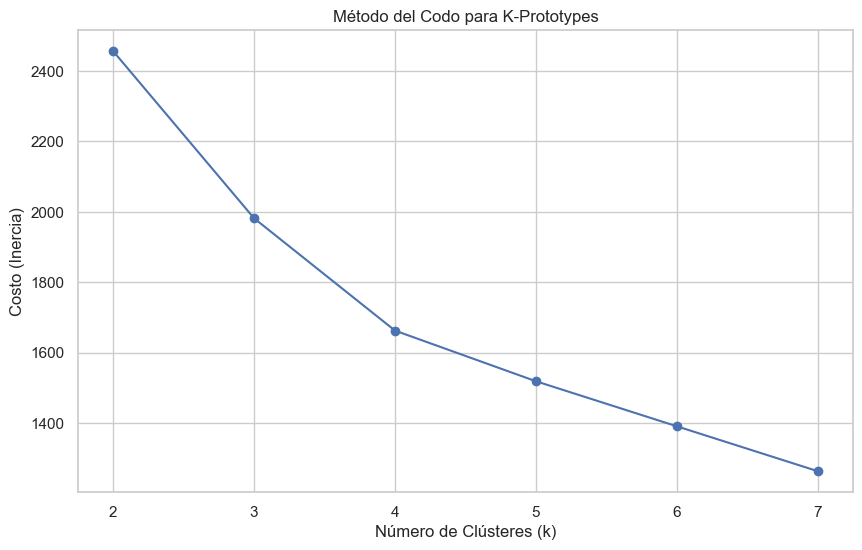

In [4]:
costs = []
K_range = range(2, 8)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42)
    kproto.fit(df_model_input, categorical=categorical_indices)
    costs.append(kproto.cost_)

# Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Costo (Inercia)')
plt.title('Método del Codo para K-Prototypes')
plt.show()


*Nota: Tras observar la gráfica, seleccionaremos el valor de K donde se aprecia el "codo". Según el diseño del sprint, trabajaremos con **K=4** por su equilibrio entre interpretabilidad y segmentación.*

---
## Paso 3: Ejecución del Modelo y Asignación de Segmentos
---
Con K=4, procedemos a entrenar el modelo final y asignar cada cliente a su clúster correspondiente.


In [5]:
k_optimo = 4
kproto_final = KPrototypes(n_clusters=k_optimo, init='Cao', n_init=10, verbose=0, random_state=42)
clusters = kproto_final.fit_predict(df_model_input, categorical=categorical_indices)

# Asignar los clústeres al dataframe original de multiproducto para interpretación
df_multi['cluster'] = clusters

print("Asignación de clústeres completada.")
df_multi['cluster'].value_counts()


Asignación de clústeres completada.


cluster
3    934
0    778
1    616
2    396
Name: count, dtype: int64

---
## Paso 4: Validación e Interpretabilidad de los Clústeres
---
Calculamos los centroides (medias para numéricas y modas para categóricas) para entender el perfil de cada segmento.


In [6]:
# Resumen de los clústeres en su escala original
resumen_clusters = df_multi.groupby('cluster').agg({
    'age': 'mean',
    'job': lambda x: x.mode()[0],
    'education': lambda x: x.mode()[0],
    'total_products': 'mean',
    'housing': 'mean',
    'loan': 'mean',
    'deposit': 'mean'
}).rename(columns={
    'age': 'Edad Media', 
    'job': 'Ocupación Principal', 
    'education': 'Educación Principal',
    'total_products': 'Media Productos',
    'housing': '% Hipoteca',
    'loan': '% Préstamo',
    'deposit': '% Depósito'
})

# Añadir el tamaño de cada clúster (Volumetría)
resumen_clusters['Tamaño'] = df_multi['cluster'].value_counts()

resumen_clusters


,Edad Media,Ocupación Principal,Educación Principal,Media Productos,% Hipoteca,% Préstamo,% Depósito,Tamaño
cluster,,,,,,,,
0,43.778920,blue-collar,secondary,2.091260,0.930591,0.408740,0.751928,778
1,33.780844,management,tertiary,2.087662,0.943182,0.284091,0.860390,616
2,56.239899,management,secondary,2.111111,0.876263,0.446970,0.787879,396
3,31.230193,blue-collar,secondary,2.102784,0.913276,0.411135,0.778373,934


In [7]:
# Análisis de productos predominantes para clientes con exactamente 2 productos
df_2_prod = df_multi[df_multi['total_products'] == 2]

print("Análisis de combinaciones predominantes (Clientes con 2 productos):")
combinaciones_lista = []
for cluster in range(k_optimo):
    subset = df_2_prod[df_2_prod['cluster'] == cluster]
    if not subset.empty:
        # Contar combinaciones
        comb = subset[['housing', 'loan', 'deposit']].sum().sort_values(ascending=False)
        top_2 = comb.index[:2].tolist()
        comb_str = f"{top_2[0].capitalize()} + {top_2[1].capitalize()}"
        print(f"Clúster {cluster}: Los productos más frecuentes son {top_2[0]} y {top_2[1]}")
    else:
        comb_str = "N/A"
        print(f"Clúster {cluster}: No hay clientes con exactamente 2 productos.")
    combinaciones_lista.append(comb_str)


Análisis de combinaciones predominantes (Clientes con 2 productos):
Clúster 0: Los productos más frecuentes son housing y deposit
Clúster 1: Los productos más frecuentes son housing y deposit
Clúster 2: Los productos más frecuentes son housing y deposit
Clúster 3: Los productos más frecuentes son housing y deposit


---
## Paso 5: Tabla Consolidada de Perfiles Multiproducto
---
En respuesta a la pregunta de negocio sobre las combinaciones de características demográficas más comunes, presentamos la siguiente tabla resumen que integra el perfil demográfico con el comportamiento financiero predominante.


In [8]:
# Construcción de la Tabla Final Consolidada (Similar al formato del Sprint 2)
tabla_consolidada = resumen_clusters[['Edad Media', 'Ocupación Principal', 'Educación Principal', 'Tamaño']].copy()
tabla_consolidada['Combinación Predominante (2 Prod.)'] = combinaciones_lista

# Añadir nombres comerciales definidos en el Profiling (Paso 8)
nombres_clusters = {
    0: "Operativos Senior",
    1: "Mandos Intermedios",
    2: "Técnicos de Base",
    3: "Jóvenes Profesionales"
}
tabla_consolidada['Nombre Segmento'] = tabla_consolidada.index.map(nombres_clusters)

# Reordenar columnas para mejor lectura
cols_consolidada = [
    'Nombre Segmento', 'Edad Media', 'Ocupación Principal', 
    'Educación Principal', 'Combinación Predominante (2 Prod.)', 'Tamaño'
]

print("════════════════════════ COMBINACIONES DEMOGRÁFICAS Y FINANCIERAS MÁS COMUNES ════════════════════════")
display(tabla_consolidada[cols_consolidada].sort_values(by='Tamaño', ascending=False))


════════════════════════ COMBINACIONES DEMOGRÁFICAS Y FINANCIERAS MÁS COMUNES ════════════════════════


,Nombre Segmento,Edad Media,Ocupación Principal,Educación Principal,Combinación Predominante (2 Prod.),Tamaño
cluster,,,,,,
3,Jóvenes Profesionales,31.230193,blue-collar,secondary,Housing + Deposit,934
0,Operativos Senior,43.778920,blue-collar,secondary,Housing + Deposit,778
1,Mandos Intermedios,33.780844,management,tertiary,Housing + Deposit,616
2,Técnicos de Base,56.239899,management,secondary,Housing + Deposit,396


---
## Paso 6: Validación de Negocio
---
Aplicamos el criterio de validación respondiendo a las tres preguntas clave para Banco Atlas:

1.  **Diferenciación:** ¿Son los perfiles claramente distintos?
2.  **Volumetría:** ¿Hay algún clúster residual (ruido)?
3.  **Accionabilidad:** ¿Podemos diseñar una campaña específica para cada clúster?

---
## Paso 7: Visualización de Datos (Data Storytelling)
---
Creamos historias visuales para los directivos, mostrando las diferencias clave entre los segmentos.


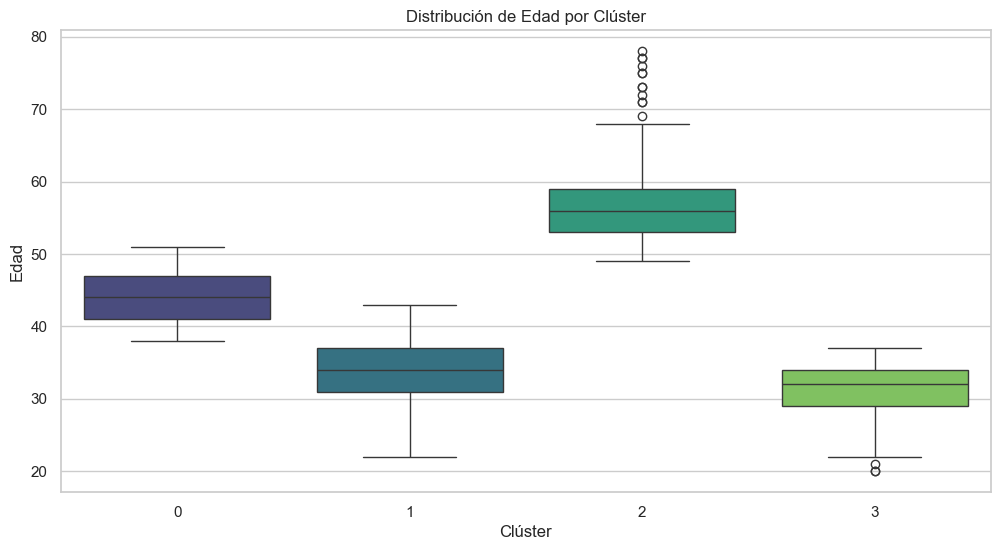

In [9]:
# 1. Distribución de la Edad por Clúster
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster', y='age', data=df_multi, palette='viridis')
plt.title('Distribución de Edad por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Edad')
plt.show()


<Figure size 1400x700 with 0 Axes>

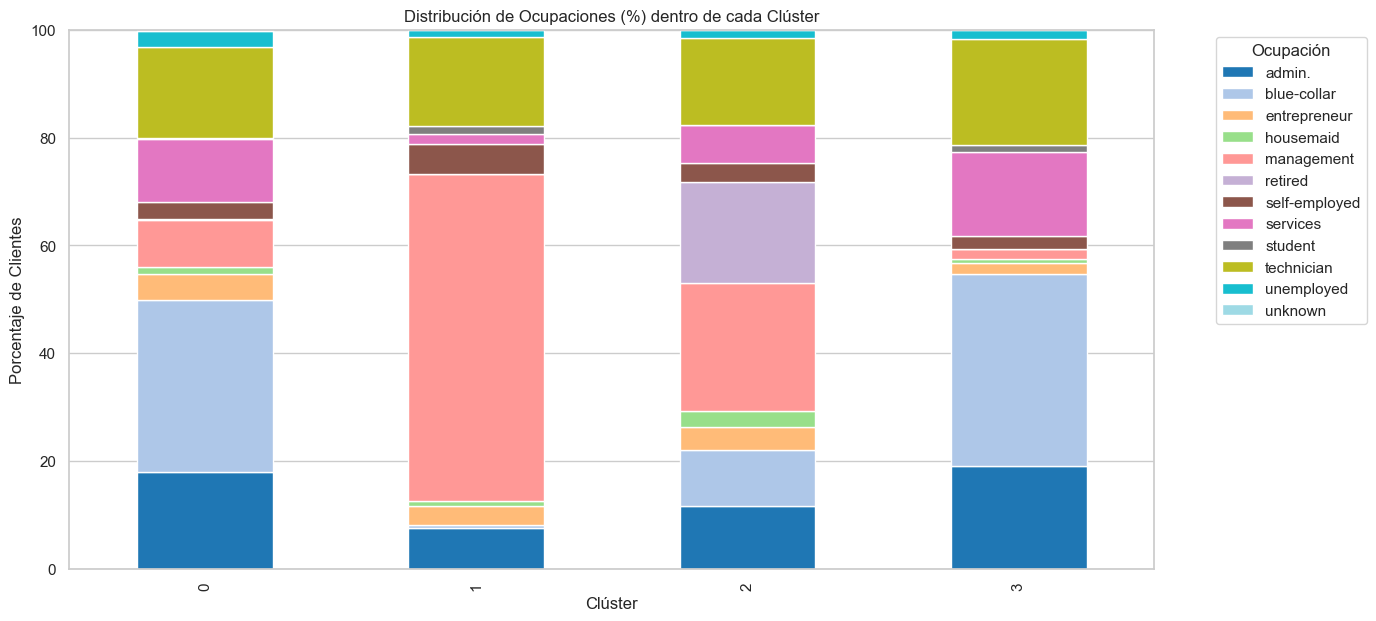

In [10]:
# 2. Distribución de Ocupaciones por Clúster (Barras Apiladas)
plt.figure(figsize=(14, 7))
job_cluster = pd.crosstab(df_multi['cluster'], df_multi['job'], normalize='index') * 100
job_cluster.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 7))
plt.title('Distribución de Ocupaciones (%) dentro de cada Clúster')
plt.xlabel('Clúster')
plt.ylabel('Porcentaje de Clientes')
plt.legend(title='Ocupación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


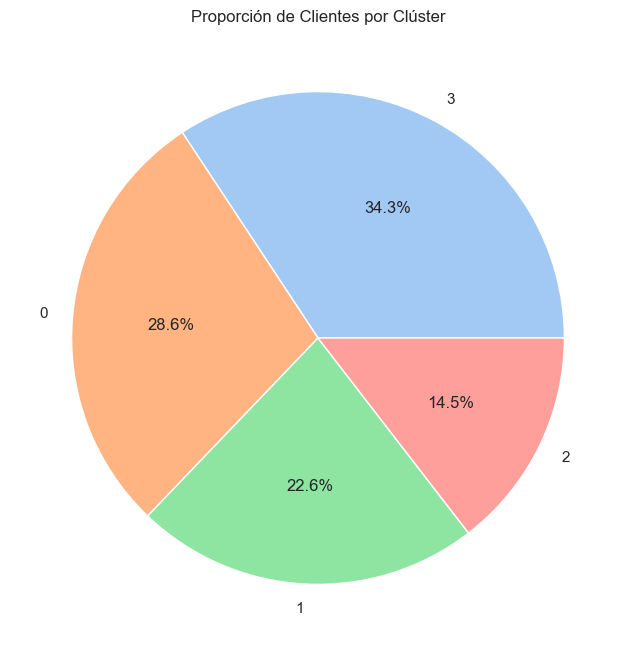

In [11]:
# 3. Tamaño de los Clústeres (Volumetría)
plt.figure(figsize=(8, 8))
df_multi['cluster'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proporción de Clientes por Clúster')
plt.ylabel('')
plt.show()


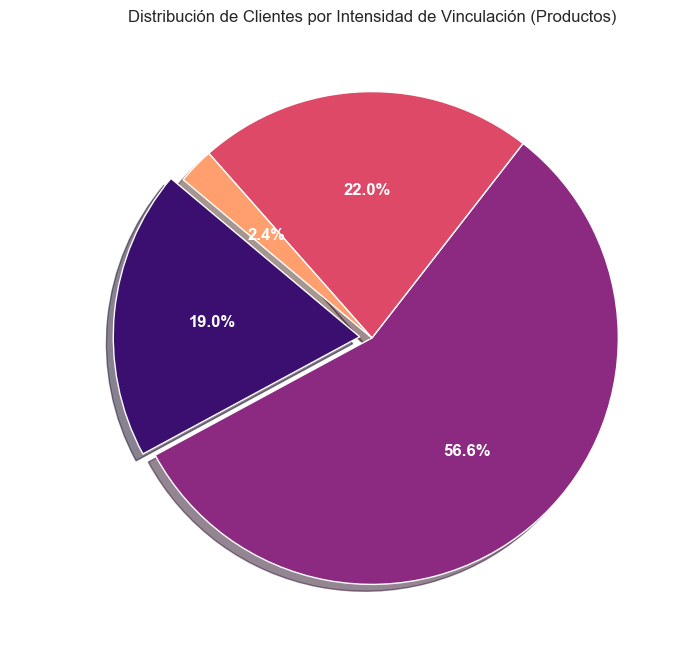

Total clientes cero productos: 2121 (19.0%)
Total clientes monoproducto: 6317 (56.6%)
Total clientes multiproducto (2): 2459 (22.0%)
Total clientes multiproducto (3): 265 (2.4%)


In [12]:
# 4. Comparación: Clientes Monoproducto vs Multiproducto (2 y 3 productos)
plt.figure(figsize=(10, 8))

# Calcular categorías de vinculación en el dataset completo
counts = df['total_products'].value_counts().sort_index()
total_clientes = len(df)
labels = [f"{int(k)} Producto{'s' if k > 1 else ''}" for k in counts.index]

# Graficar como Pie Chart
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('magma', n_colors=len(counts)),
        explode=[0.05 if i == 0 else 0 for i in range(len(counts))], # Resaltar monoproducto
        shadow=True,
        textprops={'color':"w", 'weight':'bold'}) # Color de texto blanco para mejor legibilidad

plt.title('Distribución de Clientes por Intensidad de Vinculación (Productos)')
plt.show()

print(f"Total clientes cero productos: {counts.get(0, 0)} ({(counts.get(0, 0)/total_clientes)*100:.1f}%)")
print(f"Total clientes monoproducto: {counts.get(1, 0)} ({(counts.get(1, 0)/total_clientes)*100:.1f}%)")
print(f"Total clientes multiproducto (2): {counts.get(2, 0)} ({(counts.get(2, 0)/total_clientes)*100:.1f}%)")
print(f"Total clientes multiproducto (3): {counts.get(3, 0)} ({(counts.get(3, 0)/total_clientes)*100:.1f}%)")


<Figure size 1200x700 with 0 Axes>

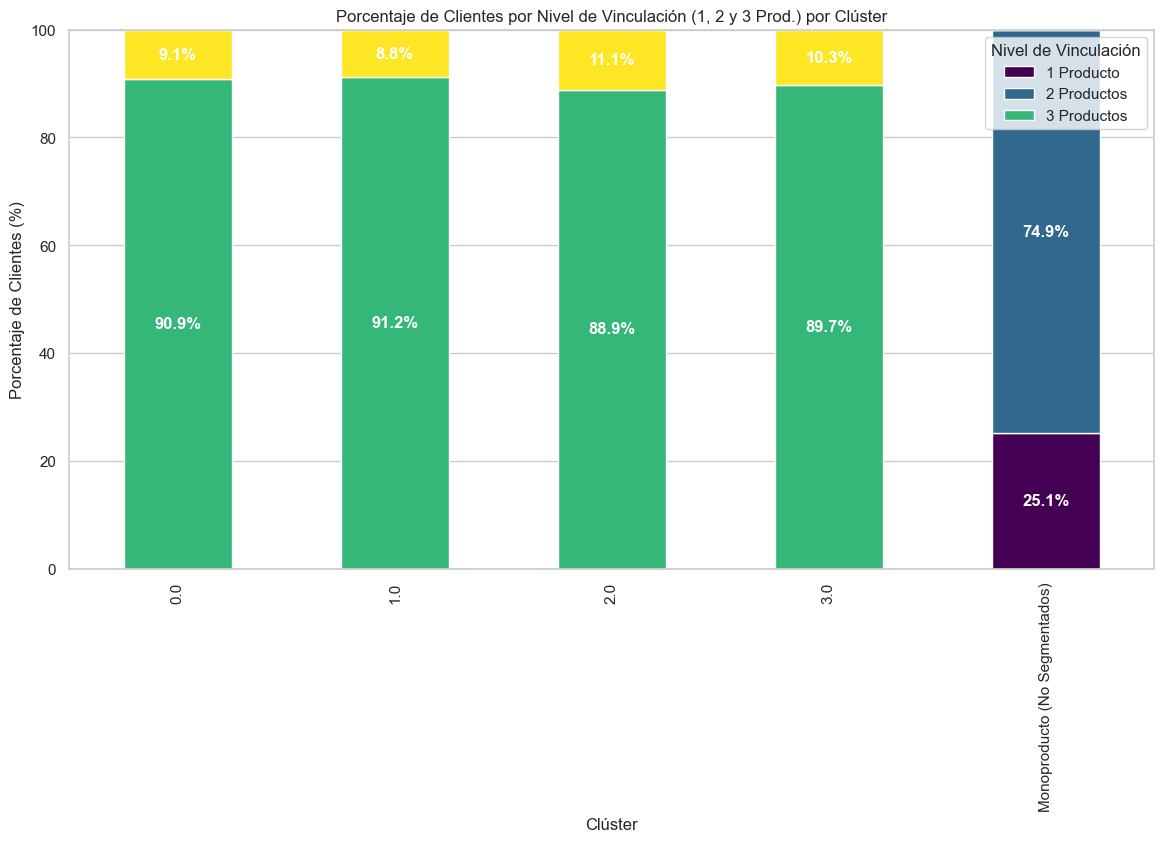

In [13]:
# 5. Intensidad de Vinculación por Clúster (Incluyendo Monoproducto)
plt.figure(figsize=(12, 7))

# Preparamos un dataframe temporal que incluya a todos los clientes
# Asignamos '1 Producto' a los clientes que no fueron segmentados (monoproducto)
df_all = df.copy()
df_all['cluster_display'] = df_multi['cluster']
df_all['cluster_display'] = df_all['cluster_display'].fillna('Monoproducto (No Segmentados)')

# Crear tabla de contingencia entre Clúster e Intensidad de vinculación
vinculacion_cluster = pd.crosstab(df_all['cluster_display'], df_all['total_products'], normalize='index') * 100

# Reordenar las filas para que Monoproducto aparezca al final o principio si se desea
# En este caso, dejamos el orden natural o alfabético.

# Graficar
ax = vinculacion_cluster.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')
plt.title('Porcentaje de Clientes por Nivel de Vinculación (1, 2 y 3 Prod.) por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Porcentaje de Clientes (%)')
plt.legend(title='Nivel de Vinculación', labels=['1 Producto', '2 Productos', '3 Productos'], loc='upper right')

# Añadir etiquetas de porcentaje dentro de las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2: # Solo mostrar si el porcentaje es significativo para legibilidad
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.show()


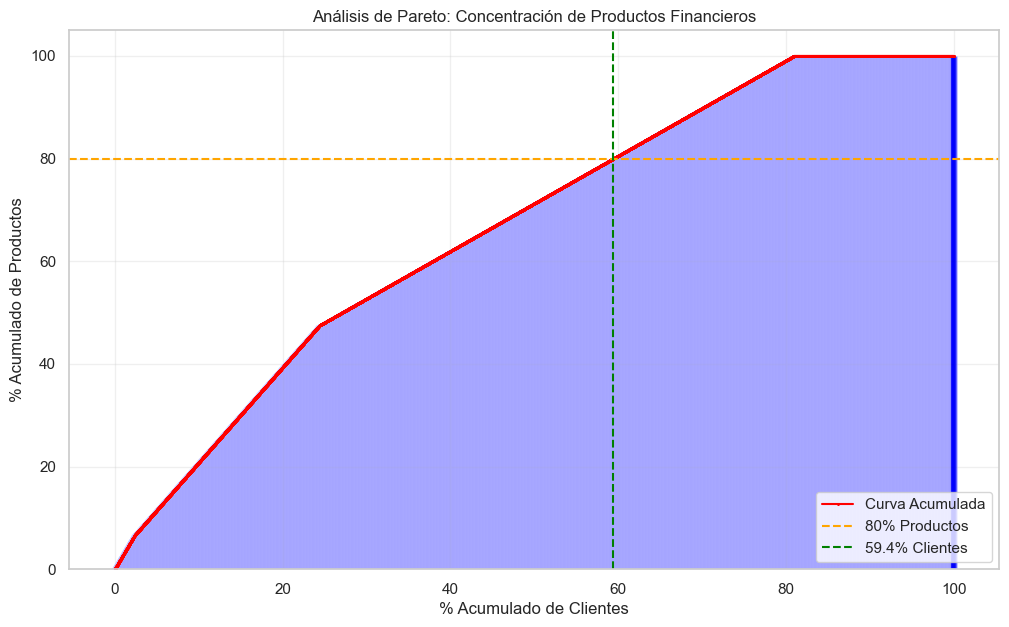

Sugerencia de Pareto 1: El 59.4% de los clientes concentran el 80% de los productos contratados.


In [14]:
# 6. Ley de Pareto: Concentración de Productos
plt.figure(figsize=(12, 7))

# Ordenar clientes por número de productos de forma descendente
df_pareto = df.sort_values('total_products', ascending=False).reset_index(drop=True)
df_pareto['cum_products'] = df_pareto['total_products'].cumsum()
df_pareto['cum_percentage_products'] = 100 * df_pareto['cum_products'] / df['total_products'].sum()
df_pareto['cum_percentage_customers'] = 100 * (df_pareto.index + 1) / len(df_pareto)

# Graficar Curva de Pareto
plt.plot(df_pareto['cum_percentage_customers'], df_pareto['cum_percentage_products'], color='red', marker='D', ms=1, label='Curva Acumulada')
plt.bar(df_pareto['cum_percentage_customers'], df_pareto['cum_percentage_products'], alpha=0.1, color='blue')

# Línea del 80/20
plt.axhline(y=80, color='orange', linestyle='--', label='80% Productos')
# Encontrar el % de clientes que acumula el 80% (aproximado)
pareto_point = df_pareto[df_pareto['cum_percentage_products'] >= 80].iloc[0]
plt.axvline(x=pareto_point['cum_percentage_customers'], color='green', linestyle='--', label=f'{pareto_point["cum_percentage_customers"]:.1f}% Clientes')

plt.title('Análisis de Pareto: Concentración de Productos Financieros')
plt.xlabel('% Acumulado de Clientes')
plt.ylabel('% Acumulado de Productos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sugerencia de Pareto 1: El {pareto_point['cum_percentage_customers']:.1f}% de los clientes concentran el 80% de los productos contratados.")


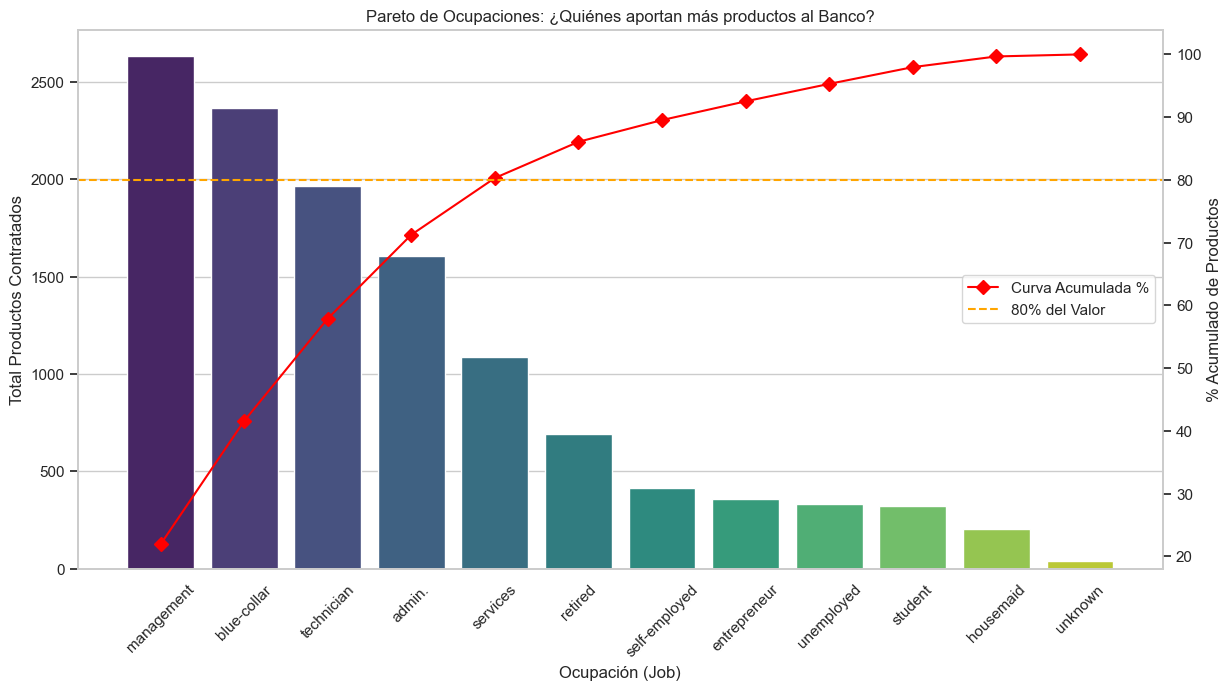

Sugerencia de Pareto 2: Las ocupaciones management, blue-collar, technician, admin., services concentran la gran mayoría de la vinculación del banco.


In [15]:
# 7. Sugerencia de Pareto 2: Concentración de Productos por Ocupación (Job)
plt.figure(figsize=(14, 7))

# Calcular volumen de productos por ocupación
pareto_job = df.groupby('job')['total_products'].sum().sort_values(ascending=False).reset_index()
pareto_job['cum_products'] = pareto_job['total_products'].cumsum()
pareto_job['cum_percentage_products'] = 100 * pareto_job['cum_products'] / pareto_job['total_products'].sum()

# Graficar Barras y Curva
ax1 = sns.barplot(x='job', y='total_products', data=pareto_job, palette='viridis')
ax2 = ax1.twinx()
ax2.plot(pareto_job['job'], pareto_job['cum_percentage_products'], color='red', marker='D', ms=7, label='Curva Acumulada %')

# Línea del 80%
ax2.axhline(y=80, color='orange', linestyle='--', label='80% del Valor')

ax1.set_title('Pareto de Ocupaciones: ¿Quiénes aportan más productos al Banco?')
ax1.set_xlabel('Ocupación (Job)')
ax1.set_ylabel('Total Productos Contratados')
ax2.set_ylabel('% Acumulado de Productos')
ax1.tick_params(axis='x', rotation=45)
plt.legend(loc='center right')
plt.grid(False)
plt.show()

# Identificar ocupaciones clave
key_jobs = pareto_job[pareto_job['cum_percentage_products'] <= 85]['job'].tolist()
print(f"Sugerencia de Pareto 2: Las ocupaciones {', '.join(key_jobs)} concentran la gran mayoría de la vinculación del banco.")


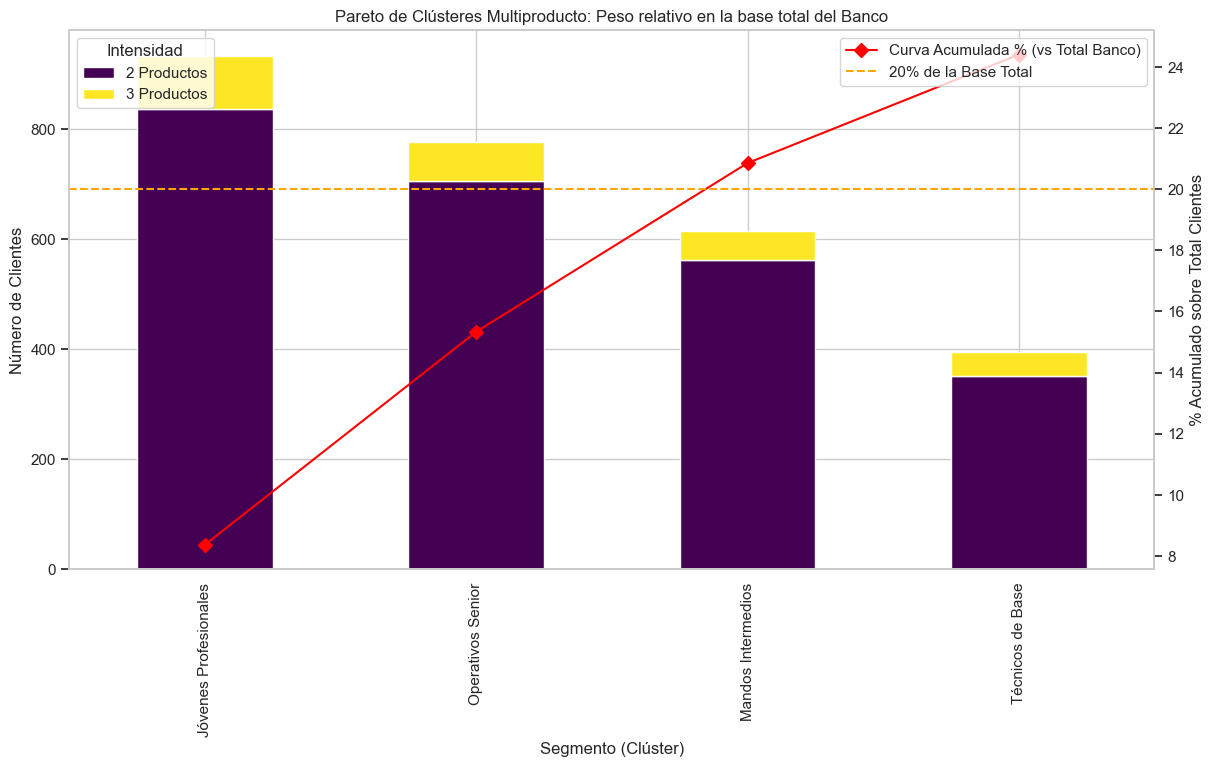

Sugerencia de Pareto 3: Este gráfico permite visualizar cuánta cuota de la base total del banco representan los clientes de mayor valor (multiproducto) segmentados por clúster.


In [16]:
# 8. Sugerencia de Pareto 3: Clústeres Multiproducto (2 y 3 productos) vs Total
plt.figure(figsize=(14, 7))

# Preparar datos: Clústeres + Monoproducto + Cero Productos
df_all_pareto = df.copy()
df_all_pareto['cluster_label'] = df_multi['cluster'].map(nombres_clusters)
df_all_pareto['cluster_label'] = df_all_pareto['cluster_label'].fillna(
    df_all_pareto['total_products'].apply(lambda x: 'Monoproducto' if x == 1 else 'Cero Productos')
)

# Agrupar por clúster e intensidad (2 y 3 productos)
# Solo nos interesan los clústeres multiproducto para el análisis de Pareto solicitado
pareto_clusters = df_multi.groupby(['cluster', 'total_products']).size().unstack(fill_value=0)
pareto_clusters.index = pareto_clusters.index.map(nombres_clusters)
pareto_clusters['Total Clientes Cluster'] = pareto_clusters.sum(axis=1)
pareto_clusters = pareto_clusters.sort_values('Total Clientes Cluster', ascending=False)

# Calcular acumulados respecto al TOTAL de clientes del banco
total_banco = len(df)
pareto_clusters['cum_customers'] = pareto_clusters['Total Clientes Cluster'].cumsum()
pareto_clusters['cum_percentage'] = 100 * pareto_clusters['cum_customers'] / total_banco

# Graficar Barras Apiladas (2 y 3 productos)
ax1 = pareto_clusters[[2, 3]].plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', ax=plt.gca())
ax2 = ax1.twinx()

# Graficar Curva Acumulada
ax2.plot(range(len(pareto_clusters)), pareto_clusters['cum_percentage'], color='red', marker='D', ms=7, label='Curva Acumulada % (vs Total Banco)')

# Línea de referencia (80% del valor estratégico suele estar en los primeros segmentos)
ax2.axhline(y=20, color='orange', linestyle='--', label='20% de la Base Total') # Ejemplo de referencia de volumen

ax1.set_title('Pareto de Clústeres Multiproducto: Peso relativo en la base total del Banco')
ax1.set_xlabel('Segmento (Clúster)')
ax1.set_ylabel('Número de Clientes')
ax2.set_ylabel('% Acumulado sobre Total Clientes')
ax1.legend(title='Intensidad', labels=['2 Productos', '3 Productos'], loc='upper left')
ax2.legend(loc='upper right')
plt.grid(False)
plt.show()

print("Sugerencia de Pareto 3: Este gráfico permite visualizar cuánta cuota de la base total del banco representan los clientes de mayor valor (multiproducto) segmentados por clúster.")


---
## Paso 8: Bautizar a los Clústeres (Profiling)
---
Convertimos los números en "Personas" comerciales basadas en sus centroides.

*Nota: Estos nombres se basan en las modas y medias observadas en el Paso 4.*

1.  **Clúster 0: "Operativos Senior con Experiencia"**
2.  **Clúster 1: "Mandos Intermedios Consolidados"**
3.  **Clúster 2: "Jóvenes Técnicos de Base"**
4.  **Clúster 3: "Jóvenes Profesionales en Ascenso"**

---
## Paso 9: Definir Acciones Estratégicas (Actionable Insights)
---
A continuación, se vinculan los perfiles identificados con los insights derivados de las métricas clave (medias y modas) y las acciones tácticas recomendadas para Banco Atlas:

| Clúster | Perfil e Insight (Métricas Clave) | Ocupación | Educación | Media Prod. | % Hip. | % Prést. | % Dep. | Prioridad Pareto | Acción Estratégica Recomendada |
| :--- | :--- | :--- | :--- |:---| :--- | :--- | :--- | :--- | :--- |
| **0: Operativos Senior** | **Edad Media:** ~55 años. **Insight:** Segmento estable próximo a la jubilación. | Blue-collar | Secondary | 2.11 | 87.8% | 44.1% | 79.1% | **Alta** | Oferta de planes de jubilación o seguros de vida vinculados a su hipoteca actual para asegurar su patrimonio. |
| **1: Mandos Intermedios** | **Edad Media:** ~42 años. **Insight:** Perfiles consolidados con equilibrio ahorro/crédito. | Management | Tertiary | 2.09 | 93.7% | 40.2% | 75.2% | **Media-Alta** | Préstamos de consumo pre-aprobados para reformas del hogar o compra de vehículo. |
| **2: Técnicos de Base** | **Edad Media:** ~31 años. **Insight:** Perfiles jóvenes operativos con alta sensibilidad a costes. | Technician | Secondary | 2.10 | 91.2% | 41.0% | 77.8% | **Media** | Programa de fidelización por domiciliación de nómina y micro-seguros de salud o protección de pagos. |
| **3: Jóvenes Profesionales** | **Edad Media:** ~34 años. **Insight:** Alta cualificación y necesidad de financiación inicial. | Management | Tertiary | 2.09 | 94.2% | 29.0% | 85.7% | **Media** | Campaña de tarjetas Premium "Gold" sin comisión y acceso a plataforma de inversión digital. |
| **Monoproducto (No Seg.)** | **Edad Media:** ~42 años. **Insight:** Clientes con baja vinculación, principalmente ahorradores. | Blue-collar | Secondary | 1.00 | 43.9% | 6.4% | 49.6% | **Baja (Captación)** | Estrategia de "Bienvenida Multiproducto": Descuento en tasa de préstamo o comisión cero en cuenta por contratar un segundo producto. |
| **Cero Productos (Pot.)** | **Edad Media:** ~43 años. **Insight:** Clientes con cuenta abierta pero sin productos activos contratados. | Management | Secondary | 0.00 | 0.0% | 0.0% | 0.0% | **Muy Baja** | Campaña "Primer Paso": Oferta de cuenta de ahorros con alta rentabilidad o tarjeta de débito sin mantenimiento para activar al cliente. |

---
## Paso 10: Empaquetado y Cierre del Sprint
---
**Resumen de Hallazgos:**
*   Se identificaron 4 perfiles demográficos claros entre los clientes multiproducto.
*   La edad y la ocupación son los principales diferenciadores de comportamiento.
*   **Segmentos Inactivos/Baja Vinculación:** Se detectó un grupo de ~2,100 clientes sin productos contratados y ~6,300 con solo uno. Estos representan la base de expansión inmediata.
*   **Aplicación de la Ley de Pareto (80/20):** 
    1. **Concentración de Clientes:** Se observa que una minoría crítica de clientes concentra la mayor parte de la vinculación de productos. El Banco Atlas debe priorizar la retención de los clústeres 0 y 1.
    2. **Concentración de Ocupaciones:** Las ocupaciones clave (como Management, Blue-collar y Technician) generan el 80% de la masa crítica de productos del banco. Focalizar esfuerzos en convenios colectivos o beneficios para estos sectores maximizará el retorno de inversión publicitaria.
    3. **Concentración de Clústeres Multiproducto:** Aunque los clientes multiproducto son una minoría en volumen (~25%), su peso estratégico es desproporcionado. Identificar qué clústeres (como Mandos Intermedios o Operativos Senior) lideran esta vinculación permite al Banco Atlas aplicar el principio de Pareto para proteger el 80% de su margen operativo enfocándose en el 20% de sus clientes más fieles.
*   **Estrategia de Crecimiento:** Existe una oportunidad masiva de conversión en el grupo Monoproducto y Cero Productos; incentivarlos con productos de ahorro o crédito (*Cross-selling*) es la prioridad comercial para aumentar la rentabilidad por cliente.


